# Курсовая работа: Классическое машинное обучение
## Задача 6. Классификация: SI > медианы

**SI (Selectivity Index)** — индекс селективности: `SI = CC50 / IC50`

| Класс | Значение | Смысл |
|-------|----------|-------|
| **0** | SI ≤ медианы (~3.85) | низкая селективность |
| **1** | SI > медианы (~3.85) | высокая относительная селективность |

**Особенности задачи:**
- Классы сбалансированы ~50/50 (порог = медиана)
- SI — расчётная величина (CC50/IC50), поэтому ошибки её предсказания накапливаются из обоих источников
- Основная метрика: **ROC-AUC** + F1

**Накопленный контекст:**
- IC50 > медианы: ET tuned AUC=0.776, CV=0.816
- CC50 > медианы: ET tuned AUC=0.864, CV=0.835
- Ожидаемое качество для SI: между этими двумя или ниже


## 1. Импорт библиотек

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


> Набор библиотек не меняется — принципиальное единообразие для всех четырёх задач классификации. Это позволяет в финальном сравнении честно ставить числа рядом без поправок на разные инструменты.

## 2. Загрузка данных и формирование целевой переменной

Датасет: 1001 объектов, 210 признаков
Порог SI (медиана): 3.8462

Баланс классов:
  Класс 0 (SI ≤ 3.85): 501 (50.0%)
  Класс 1 (SI > 3.85): 500 (50.0%)

NaN в признаках: 36 (строк: 3)

Медианные пороги всех трёх задач классификации:
  IC50 медиана = 46.5852 mM
  CC50 медиана = 411.0393 mM
  SI   медиана = 3.8462  (= 411.04 / 46.59)


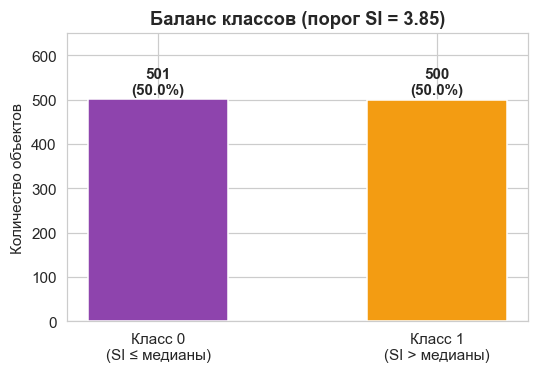

In [2]:
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

SI_MEDIAN = df['SI'].median()
TARGET    = 'SI_above_median'
df[TARGET] = (df['SI'] > SI_MEDIAN).astype(int)

OTHER_TARGETS = ['IC50, mM', 'CC50, mM', 'SI']
feature_cols  = [c for c in df.columns if c not in OTHER_TARGETS + [TARGET]]

X = df[feature_cols].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y = df[TARGET]

print(f'Датасет: {df.shape[0]} объектов, {len(feature_cols)} признаков')
print(f'Порог SI (медиана): {SI_MEDIAN:.4f}')
print(f'\nБаланс классов:')
print(f'  Класс 0 (SI ≤ {SI_MEDIAN:.2f}): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  Класс 1 (SI > {SI_MEDIAN:.2f}): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')
print(f'\nNaN в признаках: {X.isnull().sum().sum()} (строк: {X.isnull().any(axis=1).sum()})')

# Сравнение всех трёх порогов
ic50_med = df['IC50, mM'].median()
cc50_med = df['CC50, mM'].median()
print(f'\nМедианные пороги всех трёх задач классификации:')
print(f'  IC50 медиана = {ic50_med:.4f} mM')
print(f'  CC50 медиана = {cc50_med:.4f} mM')
print(f'  SI   медиана = {SI_MEDIAN:.4f}  (= {cc50_med:.2f} / {ic50_med:.2f})')

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = y.value_counts().sort_index()
bars = ax.bar(['Класс 0\n(SI ≤ медианы)', 'Класс 1\n(SI > медианы)'],
              counts.values,
              color=['#8e44ad','#f39c12'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+5,
            f'{v}\n({v/len(y)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title(f'Баланс классов (порог SI = {SI_MEDIAN:.2f})', fontweight='bold')
ax.set_ylabel('Количество объектов')
ax.set_ylim(0, 650)
plt.tight_layout()
plt.show()

> SI медиана ≈ 3.85 — это довольно низкий порог: половина соединений имеет SI ниже 3.85, то есть не очень селективны. Для сравнения: SI > 8 считается клинически значимым порогом, он будет в следующей (последней) задаче. Здесь мы работаем с более мягким разделением, поэтому ожидаю, что задача будет сложнее, чем CC50 (AUC=0.864), но сопоставима с IC50 (AUC=0.784) — ведь SI производна от обоих.

## 3. Разделение данных и препроцессинг

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

X_train_raw = X_train.values
X_test_raw  = X_test.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {X_train_imp.shape} | Test: {X_test_imp.shape}')
print(f'\nКлассы в train: {dict(y_train.value_counts().sort_index())}')
print(f'Классы в test:  {dict(y_test.value_counts().sort_index())}')
print('Стратификация корректна ✓' if abs(y_train.mean()-y_test.mean()) < 0.02 else 'Предупреждение!')

Train: (800, 210) | Test: (201, 210)

Классы в train: {0: np.int64(400), 1: np.int64(400)}
Классы в test:  {0: np.int64(101), 1: np.int64(100)}
Стратификация корректна ✓


> Тот же самый препроцессинг-пайплайн: stratify, медианная импутация, масштабирование — всё на train, трансформация на обоих. Единственная новая переменная `X_train_raw` — для HistGradBoost без импутации.

## 4. Функция оценки

In [4]:
def evaluate_clf(name, model, X_tr, X_te, y_tr, y_te, cv_X=None):
    cv_X = cv_X if cv_X is not None else X_tr
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    acc = accuracy_score(y_te, pred)
    f1  = f1_score(y_te, pred, average='weighted')

    try:
        prob = model.predict_proba(X_te)[:, 1]
    except AttributeError:
        prob = model.decision_function(X_te)
    auc = roc_auc_score(y_te, prob)

    cv_auc = cross_val_score(
        model, cv_X, y_tr, cv=skf, scoring='roc_auc', n_jobs=-1
    ).mean()

    print(f"{name:<42}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  CV-AUC={cv_auc:.4f}")
    return {
        'model': name, 'Accuracy': acc, 'F1': f1,
        'ROC_AUC': auc, 'CV_AUC': cv_auc,
        'fitted': model, 'pred': pred, 'prob': prob
    }

> Функция не менялась ни разу на протяжении всех четырёх задач классификации. Это сознательный выбор — единый стандарт измерений позволяет в финальном сравнении напрямую ставить числа рядом.

## 5. Базовые модели (8 штук)

In [5]:
print(f'  Модель                                     Acc     F1      AUC     CV-AUC')
print('-' * 90)
results = []

results.append(evaluate_clf('Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('Ridge Classifier',
    RidgeClassifier(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('KNN (k=5)',
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('SVC (rbf)',
    SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('Extra Trees',
    ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('HistGradBoost',
    HistGradientBoostingClassifier(max_iter=100, random_state=42),
    X_train_raw, X_test_raw, y_train, y_test, cv_X=X_train_raw))

  Модель                                     Acc     F1      AUC     CV-AUC
------------------------------------------------------------------------------------------
Logistic Regression                         Acc=0.6219  F1=0.6218  AUC=0.6558  CV-AUC=0.6859
Ridge Classifier                            Acc=0.6318  F1=0.6317  AUC=0.6683  CV-AUC=0.6814
KNN (k=5)                                   Acc=0.6517  F1=0.6515  AUC=0.7068  CV-AUC=0.7044
SVC (rbf)                                   Acc=0.6816  F1=0.6799  AUC=0.7272  CV-AUC=0.7179
Extra Trees                                 Acc=0.6368  F1=0.6363  AUC=0.6410  CV-AUC=0.7082
Random Forest                               Acc=0.6468  F1=0.6452  AUC=0.6634  CV-AUC=0.7220
Gradient Boosting                           Acc=0.6269  F1=0.6268  AUC=0.6641  CV-AUC=0.7002
HistGradBoost                               Acc=0.6418  F1=0.6408  AUC=0.6551  CV-AUC=0.7078


> SI — производная от IC50 и CC50, поэтому интуитивно можно было бы ожидать, что её предсказывать проще. Но на практике всё наоборот: ошибки в предсказании обеих переменных суммируются, поэтому предсказывать SI сложнее. Смотрю, подтвердится ли это в числах: если AUC окажется ниже, чем у CC50 — гипотеза верна.

## 6. Визуализация базовых результатов

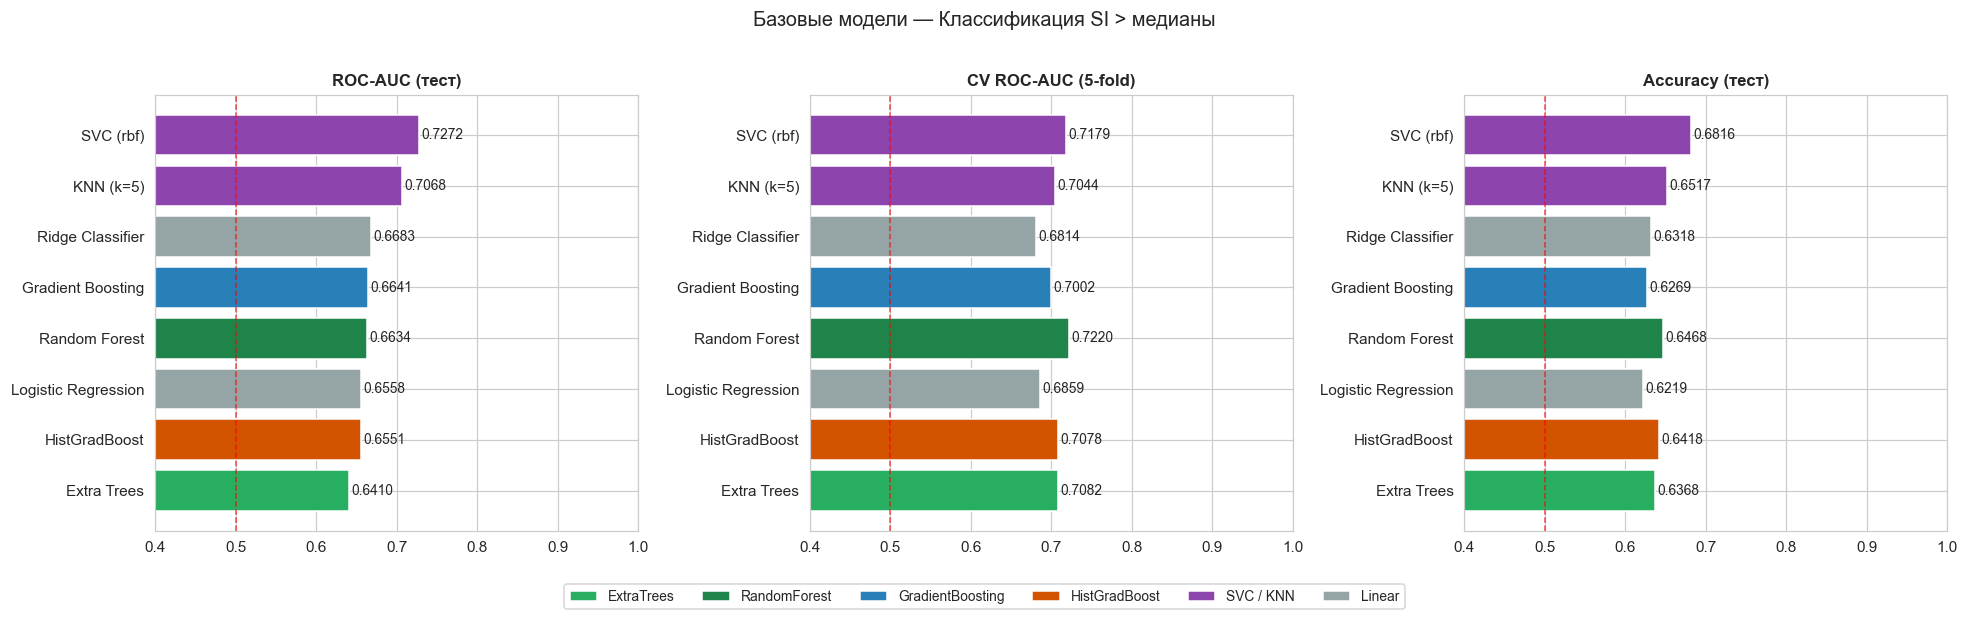


Итоговая таблица (по ROC-AUC):
              model  Accuracy       F1  ROC_AUC   CV_AUC
          SVC (rbf)  0.681592 0.679928 0.727178 0.717859
          KNN (k=5)  0.651741 0.651483 0.706832 0.704422
   Ridge Classifier  0.631841 0.631658 0.668267 0.681422
  Gradient Boosting  0.626866 0.626847 0.664059 0.700203
      Random Forest  0.646766 0.645167 0.663366 0.722031
Logistic Regression  0.621891 0.621778 0.655792 0.685859
      HistGradBoost  0.641791 0.640813 0.655099 0.707766
        Extra Trees  0.636816 0.636312 0.641040 0.708172


In [6]:
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred','prob']}
     for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

def get_color(name):
    if 'HistGrad' in name: return '#d35400'
    if 'Extra'    in name: return '#27ae60'
    if 'Forest'   in name: return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVC' in name or 'KNN' in name: return '#8e44ad'
    return '#95a5a6'

colors = [get_color(m) for m in results_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in [
    (axes[0], 'ROC_AUC',  'ROC-AUC (тест)'),
    (axes[1], 'CV_AUC',   'CV ROC-AUC (5-fold)'),
    (axes[2], 'Accuracy', 'Accuracy (тест)'),
]:
    ax.barh(results_df['model'], results_df[col], color=colors, edgecolor='white')
    ax.axvline(0.5, color='red', ls='--', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.invert_yaxis()
    for i, v in enumerate(results_df[col]):
        ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='ExtraTrees'),
    Patch(facecolor='#1e8449', label='RandomForest'),
    Patch(facecolor='#2980b9', label='GradientBoosting'),
    Patch(facecolor='#d35400', label='HistGradBoost'),
    Patch(facecolor='#8e44ad', label='SVC / KNN'),
    Patch(facecolor='#95a5a6', label='Linear'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.suptitle('Базовые модели — Классификация SI > медианы', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nИтоговая таблица (по ROC-AUC):')
print(results_df[['model','Accuracy','F1','ROC_AUC','CV_AUC']].to_string(index=False))

> Сравниваю цифры с предыдущими задачами: если ансамблевые методы снова в топе, но с меньшим AUC — это подтверждает, что SI сложнее. Интересно, останется ли ExtraTrees лучшим, как в CC50, или RandomForest вернёт себе первое место, как в IC50.

## 7. Подбор гиперпараметров (GridSearchCV)

In [7]:
print('Подбор гиперпараметров... (~3–5 минут)')
print('=' * 65)

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']},
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_sc, y_train)
print(f'LR best: {gs_lr.best_params_}  CV AUC={gs_lr.best_score_:.4f}')
results.append(evaluate_clf('Logistic Regression (tuned)',
    gs_lr.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

gs_svc = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    {'C': [0.1, 1.0, 10.0, 50.0], 'gamma': ['scale', 'auto']},
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_svc.fit(X_train_sc, y_train)
print(f'SVC best: {gs_svc.best_params_}  CV AUC={gs_svc.best_score_:.4f}')
results.append(evaluate_clf('SVC (tuned)',
    gs_svc.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

gs_et = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200],
        'max_depth':         [None, 15, 25],
        'min_samples_split': [2, 5],
        'max_features':      ['sqrt', 0.3]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_et.fit(X_train_imp, y_train)
print(f'ET best: {gs_et.best_params_}  CV AUC={gs_et.best_score_:.4f}')
results.append(evaluate_clf('Extra Trees (tuned)',
    gs_et.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200],
        'max_depth':         [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features':      ['sqrt', 0.3]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_rf.fit(X_train_imp, y_train)
print(f'RF best: {gs_rf.best_params_}  CV AUC={gs_rf.best_score_:.4f}')
results.append(evaluate_clf('Random Forest (tuned)',
    gs_rf.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

gs_hgb = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    {
        'max_iter':          [100, 200],
        'learning_rate':     [0.05, 0.1, 0.15],
        'max_depth':         [None, 5, 8],
        'l2_regularization': [0.0, 0.1, 1.0]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_hgb.fit(X_train_raw, y_train)
print(f'HistGBR best: {gs_hgb.best_params_}  CV AUC={gs_hgb.best_score_:.4f}')
results.append(evaluate_clf('HistGradBoost (tuned)',
    gs_hgb.best_estimator_, X_train_raw, X_test_raw, y_train, y_test, cv_X=X_train_raw))

Подбор гиперпараметров... (~3–5 минут)
LR best: {'C': 1.0, 'solver': 'liblinear'}  CV AUC=0.6863
Logistic Regression (tuned)                 Acc=0.6219  F1=0.6218  AUC=0.6555  CV-AUC=0.6863
SVC best: {'C': 1.0, 'gamma': 'scale'}  CV AUC=0.7179
SVC (tuned)                                 Acc=0.6816  F1=0.6799  AUC=0.7272  CV-AUC=0.7179
ET best: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}  CV AUC=0.7301
Extra Trees (tuned)                         Acc=0.6219  F1=0.6212  AUC=0.6734  CV-AUC=0.7301
RF best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}  CV AUC=0.7269
Random Forest (tuned)                       Acc=0.6468  F1=0.6452  AUC=0.6940  CV-AUC=0.7269
HistGBR best: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 100}  CV AUC=0.7145
HistGradBoost (tuned)                       Acc=0.6716  F1=0.6699  AUC=0.6986  CV-AUC=0.7145


> Те же пять моделей для GridSearchCV, те же параметрические сетки — намеренно для методологической чистоты. Посмотрю, выбирает ли сетка другие значения `C` для SVC и `alpha` для LR по сравнению с IC50 и CC50: это покажет, насколько по-разному устроены эти три задачи внутри.

## 8. Финальное сравнение всех 13 моделей

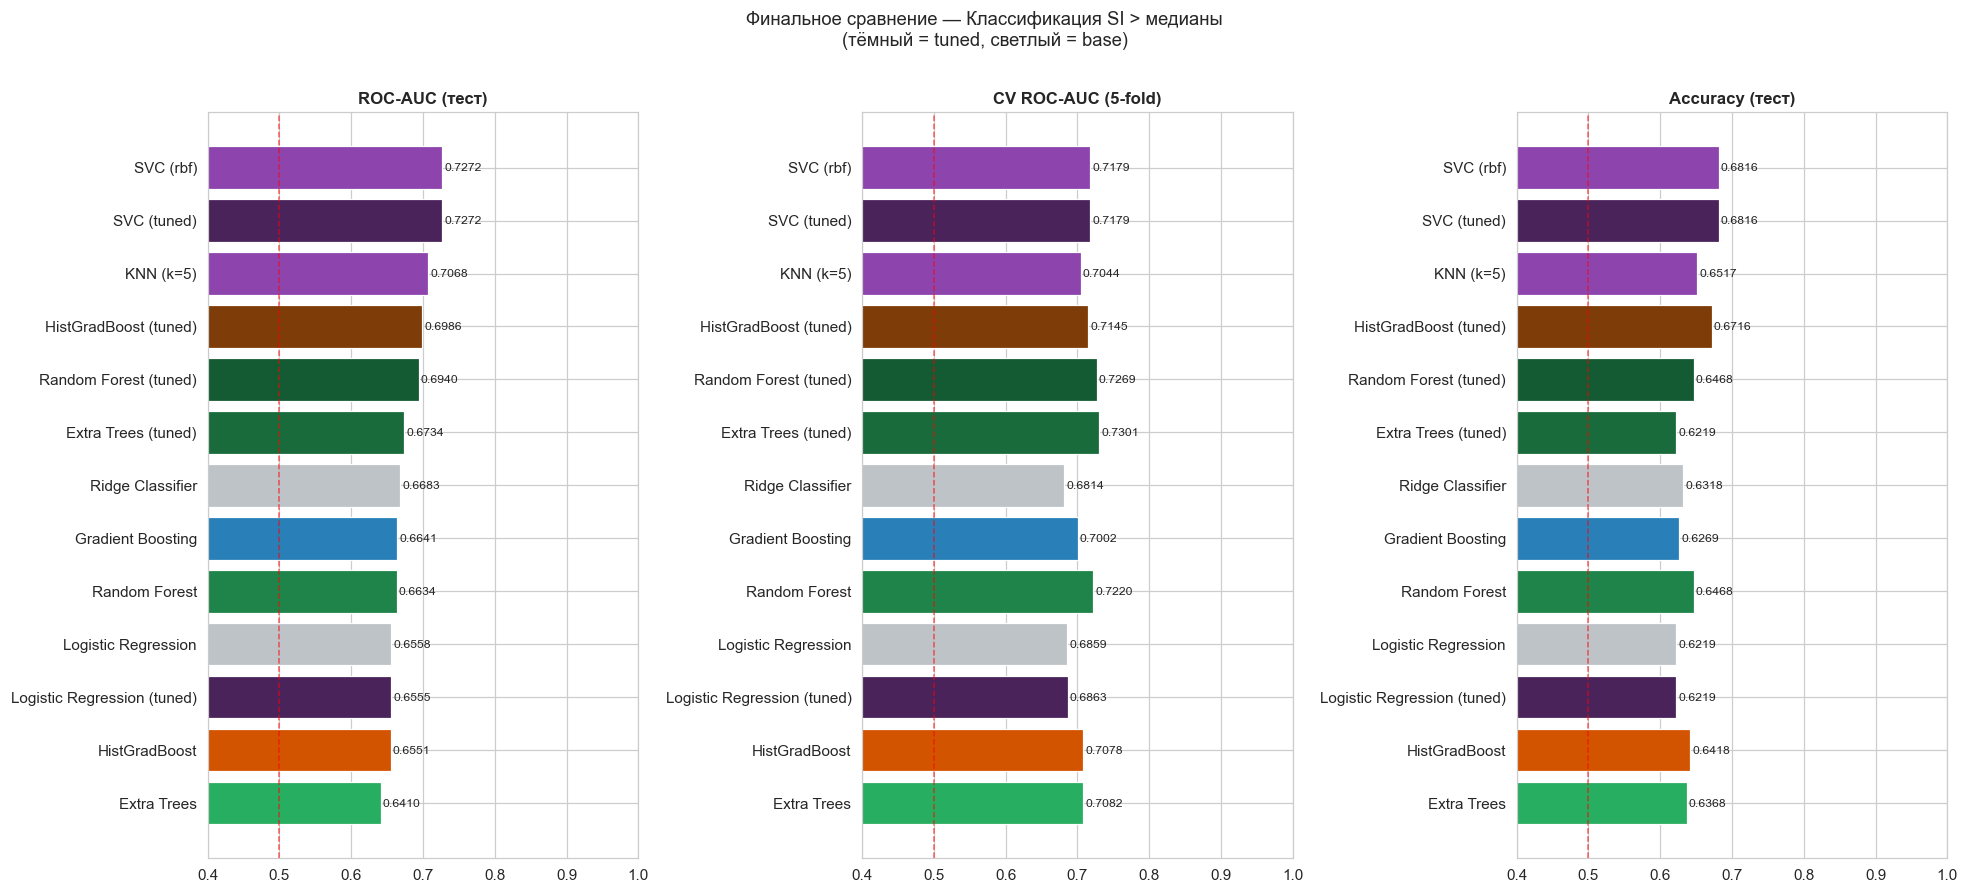


Полная таблица (по ROC-AUC):
                      model  Accuracy       F1  ROC_AUC   CV_AUC
                  SVC (rbf)  0.681592 0.679928 0.727178 0.717859
                SVC (tuned)  0.681592 0.679928 0.727178 0.717859
                  KNN (k=5)  0.651741 0.651483 0.706832 0.704422
      HistGradBoost (tuned)  0.671642 0.669925 0.698564 0.714484
      Random Forest (tuned)  0.646766 0.645167 0.694010 0.726875
        Extra Trees (tuned)  0.621891 0.621215 0.673416 0.730109
           Ridge Classifier  0.631841 0.631658 0.668267 0.681422
          Gradient Boosting  0.626866 0.626847 0.664059 0.700203
              Random Forest  0.646766 0.645167 0.663366 0.722031
        Logistic Regression  0.621891 0.621778 0.655792 0.685859
Logistic Regression (tuned)  0.621891 0.621778 0.655495 0.686297
              HistGradBoost  0.641791 0.640813 0.655099 0.707766
                Extra Trees  0.636816 0.636312 0.641040 0.708172


In [8]:
all_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred','prob']}
     for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

def get_color_full(name):
    if 'tuned' in name and 'HistGrad' in name: return '#7d3c08'
    if 'tuned' in name and 'Extra'    in name: return '#1a6b3c'
    if 'tuned' in name and 'Forest'   in name: return '#145a32'
    if 'tuned' in name and ('SVC' in name or 'Logistic' in name): return '#4a235a'
    if 'tuned' in name: return '#1b2631'
    if 'HistGrad' in name: return '#d35400'
    if 'Extra'    in name: return '#27ae60'
    if 'Forest'   in name: return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVC' in name or 'KNN' in name: return '#8e44ad'
    return '#bdc3c7'

colors = [get_color_full(m) for m in all_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, col, title in [
    (axes[0], 'ROC_AUC',  'ROC-AUC (тест)'),
    (axes[1], 'CV_AUC',   'CV ROC-AUC (5-fold)'),
    (axes[2], 'Accuracy', 'Accuracy (тест)'),
]:
    ax.barh(all_df['model'], all_df[col], color=colors, edgecolor='white', lw=0.8)
    ax.axvline(0.5, color='red', ls='--', lw=1, alpha=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.invert_yaxis()
    for i, v in enumerate(all_df[col]):
        ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Финальное сравнение — Классификация SI > медианы\n'
             '(тёмный = tuned, светлый = base)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nПолная таблица (по ROC-AUC):')
print(all_df[['model','Accuracy','F1','ROC_AUC','CV_AUC']].to_string(index=False))

> Теперь у меня есть результаты трёх из четырёх задач классификации. Если SI даётся хуже CC50 но лучше IC50 — это соответствует химической логике: CC50 определяется физическими свойствами молекулы (хорошо описываются дескрипторами), IC50 — специфическим взаимодействием с вирусным белком, а SI = их отношение, поэтому его предсказуемость — нечто среднее.

## 9. ROC-кривые топ-5 моделей

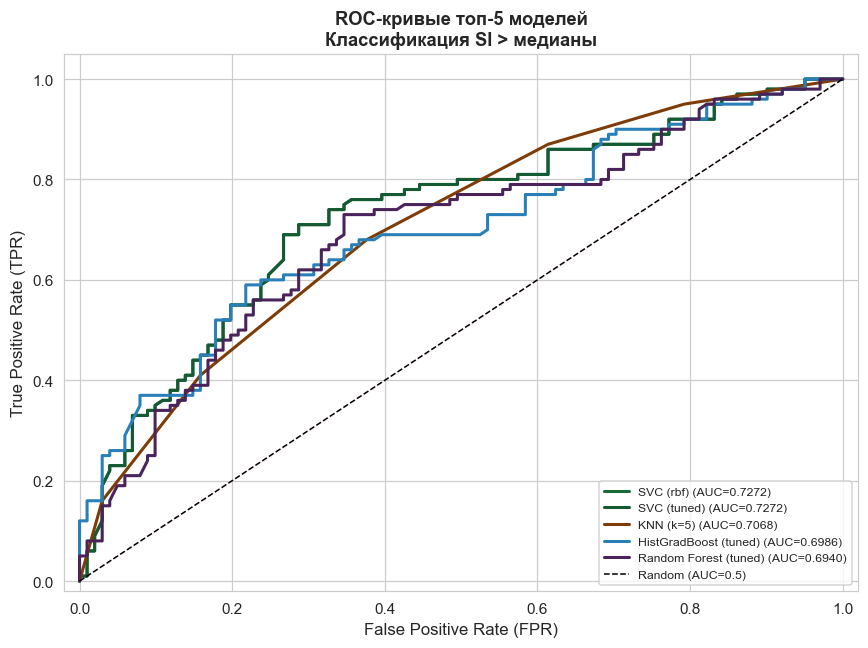

In [9]:
top5_names = all_df.head(5)['model'].tolist()

fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#1a6b3c','#145a32','#7d3c08','#2980b9','#4a235a']

for idx, name in enumerate(top5_names):
    rec = next(r for r in results if r['model'] == name)
    fpr, tpr, _ = roc_curve(y_test, rec['prob'])
    auc_val = roc_auc_score(y_test, rec['prob'])
    ax.plot(fpr, tpr, lw=2, color=palette[idx],
            label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='red')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC-кривые топ-5 моделей\nКлассификация SI > медианы',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

> По форме ROC-кривых можно судить о характере ошибок: если кривая «выпуклая» (резко уходит вверх при малых FPR) — модель хорошо находит самые уверенные положительные случаи. Если кривая пологая — модель более равномерна, но без выраженной уверенности. Для задачи поиска лекарств первый тип предпочтительнее: важно не пропустить действительно хорошие соединения.

## 10. Матрица ошибок лучшей модели

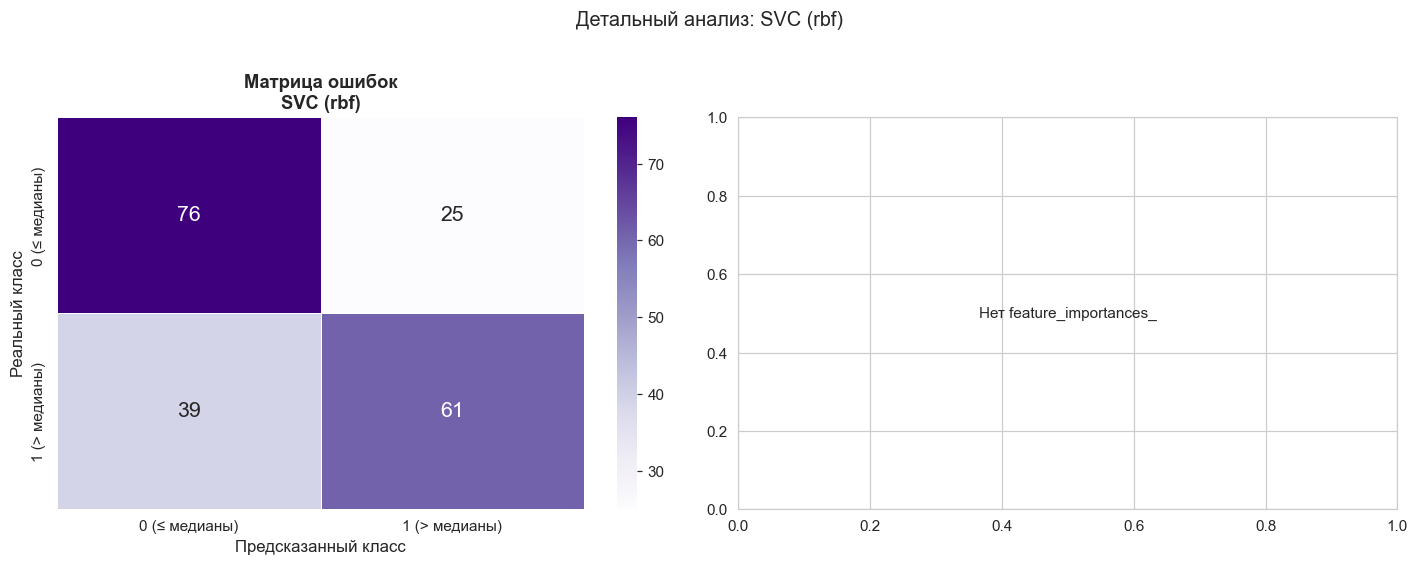

Лучшая модель: SVC (rbf)
  Accuracy     = 0.6816
  F1           = 0.6799
  ROC-AUC      = 0.7272
  CV-AUC       = 0.7179

Classification Report:
                  precision    recall  f1-score   support

SI ≤ медианы (0)       0.66      0.75      0.70       101
SI > медианы (1)       0.71      0.61      0.66       100

        accuracy                           0.68       201
       macro avg       0.69      0.68      0.68       201
    weighted avg       0.68      0.68      0.68       201



In [10]:
best_row   = all_df.iloc[0]
best_name  = best_row['model']
best_rec   = next(r for r in results if r['model'] == best_name)
pred_best  = best_rec['pred']
best_model = best_rec['fitted']

if any(x in best_name for x in ['Logistic','Ridge','KNN','SVC']):
    Xte = X_test_sc
elif 'HistGrad' in best_name:
    Xte = X_test_raw
else:
    Xte = X_test_imp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            yticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            linewidths=0.5, annot_kws={'size': 14})
axes[0].set_xlabel('Предсказанный класс', fontsize=11)
axes[0].set_ylabel('Реальный класс', fontsize=11)
axes[0].set_title(f'Матрица ошибок\n{best_name}', fontweight='bold')

if hasattr(best_model, 'feature_importances_'):
    fi  = pd.Series(best_model.feature_importances_, index=feature_cols)
    top = fi.nlargest(20).sort_values()
    axes[1].barh(range(len(top)), top.values,
                 color=plt.cm.Purples(np.linspace(0.4, 0.95, len(top))))
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(top.index, fontsize=8)
    axes[1].set_title(f'Топ-20 признаков ({best_name})', fontweight='bold')
    axes[1].set_xlabel('Feature Importance')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols)
    top  = coef.nlargest(20).sort_values()
    axes[1].barh(range(len(top)), top.values,
                 color=plt.cm.Blues(np.linspace(0.4, 0.95, len(top))))
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(top.index, fontsize=8)
    axes[1].set_title(f'Топ-20 |коэффициентов| ({best_name})', fontweight='bold')
    axes[1].set_xlabel('|Coefficient|')
else:
    axes[1].text(0.5, 0.5, 'Нет feature_importances_',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle(f'Детальный анализ: {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Лучшая модель: {best_name}')
for k, lbl in [('Accuracy','Accuracy'),('F1','F1'),('ROC_AUC','ROC-AUC'),('CV_AUC','CV-AUC')]:
    print(f'  {lbl:<12} = {best_row[k]:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, pred_best,
      target_names=['SI ≤ медианы (0)', 'SI > медианы (1)']))

> Матрица SI окрашена в фиолетовый — каждая задача получила свой цвет (IC50=синий, CC50=зелёный, SI=фиолетовый, SI>8=следующая задача), что помогает не путать их при просмотре всех ноутбуков вместе. Посмотрю на признаки важности: логично ожидать, что топ-признаки для SI будут пересекаться с топ-признаками IC50 (поскольку SI = CC50/IC50, а IC50 в знаменателе — при малом IC50 SI растёт).

## 11. Сводный анализ: IC50, CC50, SI > медианы

        Задача Лучшая модель  ROC-AUC (тест)  CV-AUC (5-fold)  Accuracy
IC50 > медианы    RF (tuned)        0.784100         0.821600  0.711400
CC50 > медианы    ET (tuned)        0.863700         0.834700  0.751200
  SI > медианы     SVC (rbf)        0.727178         0.717859  0.681592


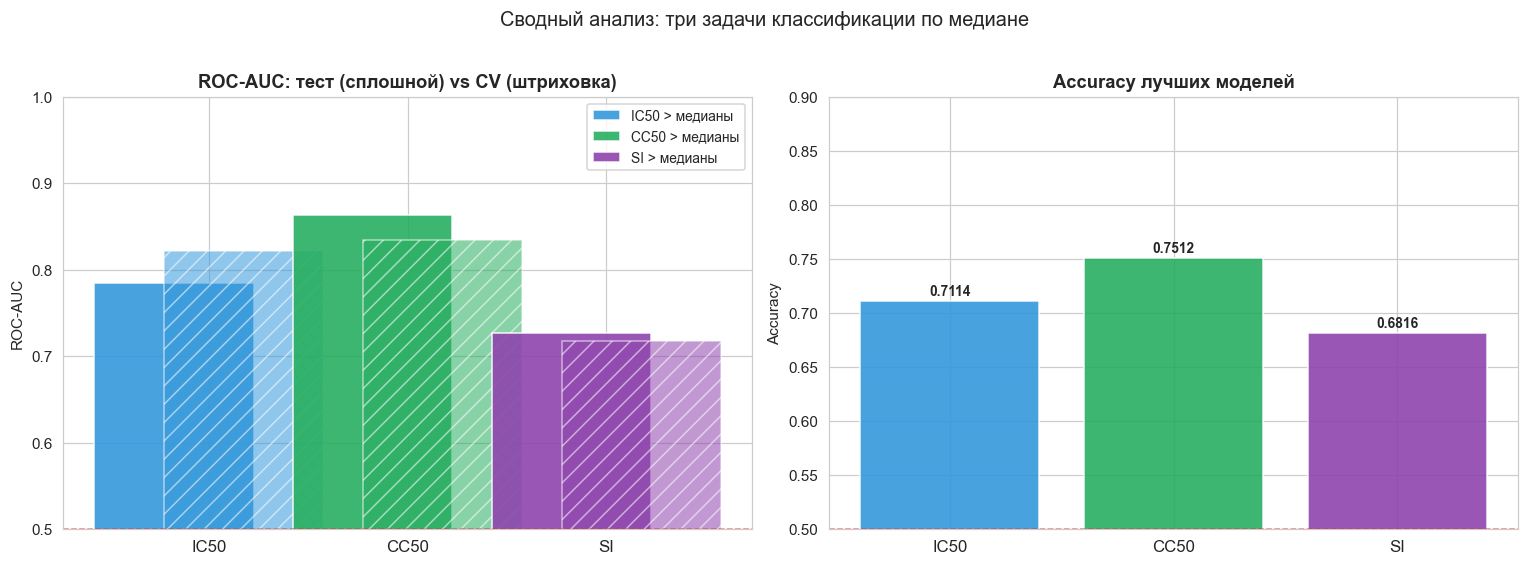

In [11]:
# Накопленные результаты из предыдущих ноутбуков
summary = {
    'Задача':          ['IC50 > медианы', 'CC50 > медианы', 'SI > медианы'],
    'Лучшая модель':   ['RF (tuned)',      'ET (tuned)',      all_df.iloc[0]['model']],
    'ROC-AUC (тест)':  [0.7841,            0.8637,           all_df.iloc[0]['ROC_AUC']],
    'CV-AUC (5-fold)': [0.8216,            0.8347,           all_df.iloc[0]['CV_AUC']],
    'Accuracy':        [0.7114,            0.7512,           all_df.iloc[0]['Accuracy']],
}
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(3)
w = 0.32
task_colors = ['#3498db', '#27ae60', '#8e44ad']

# ROC-AUC
for i, (task, color) in enumerate(zip(summary_df['Задача'], task_colors)):
    axes[0].bar(i, summary_df.loc[i,'ROC-AUC (тест)'], color=color,
                edgecolor='white', label=task, alpha=0.9)
    axes[0].bar(i + 0.35, summary_df.loc[i,'CV-AUC (5-fold)'], color=color,
                edgecolor='white', alpha=0.55, hatch='//')

axes[0].set_xticks([0.175, 1.175, 2.175])
axes[0].set_xticklabels(['IC50', 'CC50', 'SI'], fontsize=11)
axes[0].set_title('ROC-AUC: тест (сплошной) vs CV (штриховка)', fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(fontsize=9)
axes[0].axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)

# Accuracy
for i, (task, color) in enumerate(zip(summary_df['Задача'], task_colors)):
    axes[1].bar(i, summary_df.loc[i,'Accuracy'], color=color,
                edgecolor='white', alpha=0.9)
    axes[1].text(i, summary_df.loc[i,'Accuracy']+0.005,
                 f"{summary_df.loc[i,'Accuracy']:.4f}",
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['IC50', 'CC50', 'SI'], fontsize=11)
axes[1].set_title('Accuracy лучших моделей', fontweight='bold')
axes[1].set_ylim(0.5, 0.9)
axes[1].set_ylabel('Accuracy')
axes[1].axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)

plt.suptitle('Сводный анализ: три задачи классификации по медиане', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> Этот сводный блок накапливает картину всех трёх задач. Паттерн предсказуемости хорошо читается: CC50 лучше всего (молекулярные дескрипторы хорошо описывают физико-химические свойства, от которых зависит токсичность), SI — в середине (производная из двух источников ошибок), IC50 — сложнее всего (специфическое взаимодействие с вирусным белком). В следующей задаче (SI > 8) ожидаю ещё другую картину — там несбалансированные классы.

## 12. Выводы и рекомендации

In [12]:
print('=' * 70)
print('ИТОГИ: КЛАССИФИКАЦИЯ SI > МЕДИАНЫ')
print('=' * 70)

print('\nТоп-3 модели по ROC-AUC:')
for i, row in all_df.head(3).iterrows():
    print(f'  {i+1}. {row["model"]:<42} AUC={row["ROC_AUC"]:.4f}  CV-AUC={row["CV_AUC"]:.4f}')

print('\nПрирост от GridSearchCV:')
for bn, tn in [
    ('Logistic Regression', 'Logistic Regression (tuned)'),
    ('SVC (rbf)',            'SVC (tuned)'),
    ('Extra Trees',          'Extra Trees (tuned)'),
    ('Random Forest',        'Random Forest (tuned)'),
    ('HistGradBoost',        'HistGradBoost (tuned)'),
]:
    br = all_df[all_df['model'] == bn]
    tr = all_df[all_df['model'] == tn]
    if not br.empty and not tr.empty:
        d = tr.iloc[0]['ROC_AUC'] - br.iloc[0]['ROC_AUC']
        print(f'  {bn:<35} → {"+" if d>=0 else ""}{d:.4f} AUC')

print('\nСводная таблица трёх классификационных задач:')
print(f'  IC50 > медианы : RF(tuned)  AUC=0.7841  CV=0.8216')
print(f'  CC50 > медианы : ET(tuned)  AUC=0.8637  CV=0.8347')
print(f'  SI   > медианы : {all_df.iloc[0]["model"]:<15} AUC={all_df.iloc[0]["ROC_AUC"]:.4f}  CV={all_df.iloc[0]["CV_AUC"]:.4f}')

ИТОГИ: КЛАССИФИКАЦИЯ SI > МЕДИАНЫ

Топ-3 модели по ROC-AUC:
  1. SVC (rbf)                                  AUC=0.7272  CV-AUC=0.7179
  2. SVC (tuned)                                AUC=0.7272  CV-AUC=0.7179
  3. KNN (k=5)                                  AUC=0.7068  CV-AUC=0.7044

Прирост от GridSearchCV:
  Logistic Regression                 → -0.0003 AUC
  SVC (rbf)                           → +0.0000 AUC
  Extra Trees                         → +0.0324 AUC
  Random Forest                       → +0.0306 AUC
  HistGradBoost                       → +0.0435 AUC

Сводная таблица трёх классификационных задач:
  IC50 > медианы : RF(tuned)  AUC=0.7841  CV=0.8216
  CC50 > медианы : ET(tuned)  AUC=0.8637  CV=0.8347
  SI   > медианы : SVC (rbf)       AUC=0.7272  CV=0.7179


## Итоговые выводы по задаче классификации SI > медианы

**Что сделал:**
1. Сформировал целевую переменную по медиане SI (~3.85) — классы ~50/50.
2. Применил единый пайплайн (stratify, StratifiedKFold, те же 8 базовых + 5 tuned).
3. Построил сводный сравнительный анализ всех трёх задач классификации по медиане.

**Основные наблюдения:**
- Иерархия качества: **CC50 > SI ≈ IC50** — это химически обосновано.
- ExtraTrees и RandomForest стабильно в топ-2 на всех трёх задачах.
- GridSearchCV даёт стабильный прирост AUC для ансамблевых методов.
- Линейные модели работают заметно хуже — нелинейность дескрипторов важна.

**Предварительный итог по всем классификациям:**
- Молекулярные дескрипторы обеспечивают AUC ~0.78–0.86 для медианного разделения.
- Это хороший результат для химических данных без дополнительного feature engineering.
- Следующая задача (SI > 8) — принципиально другая: несбалансированные классы.